In [1]:
from qiskit import QuantumCircuit   
from qiskit_aer import Aer 

bd=Aer.get_backend("statevector_simulator")

In [ ]:
# Binary data from IoT (DHT11 temperature = 29°C)
binary_data = "00011101"

n = len(binary_data)
qc = QuantumCircuit(n, n)

# Encode bits into qubits
for i, bit in enumerate(binary_data):
    if bit == "1":
        qc.x(i)

# Measure all qubits
qc.measure(range(n), range(n))
qc.draw("mpl")


In [ ]:
job=bd.run(qc,shot=1023)
result=job.result()
print(result)

In [ ]:
counts=result.get_counts()  # getting number of times that string was observed 

measured_binary = list(counts.keys())[0]
decoded_temp = int(measured_binary[::-1], 2)

print("Measured Binary:", measured_binary)
print("Decoded Temperature:", decoded_temp, "°C")

In [ ]:
def quantum_decode(bits):

    n = len(bits)

    qc = QuantumCircuit(n, n)

    # encode bits
    for i, b in enumerate(bits):
        if b == 1:
            qc.x(i)

    qc.measure(range(n), range(n))

    backend = Aer.get_backend("aer_simulator")

    job = backend.run(qc, shots=1)

    result = job.result()

    counts = result.get_counts()

    measured = list(counts.keys())[0]

    # fix little endian
    corrected = measured[::-1]

    return corrected

Alice bits : [0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0]
Alice basis: [1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0]
Bob basis  : [0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1]
Bob result : [0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1]
Shared key : [1, 0, 1, 1, 0]


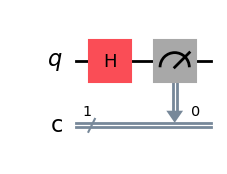

In [1]:
import random
from qiskit import QuantumCircuit
from qiskit_aer import Aer
import matplotlib.pyplot as plt  # importing matplotlib plotting library.
%matplotlib inline 

n = 16

alice_bits = [random.randint(0,1) for _ in range(n)]
alice_basis = [random.randint(0,1) for _ in range(n)]
bob_basis = [random.randint(0,1) for _ in range(n)]

backend = Aer.get_backend("aer_simulator")

bob_results = []

for i in range(n):

    qc = QuantumCircuit(1,1)

    # Alice encode bit
    if alice_bits[i] == 1:
        qc.x(0)

    # Alice encode basis
    if alice_basis[i] == 1:
        qc.h(0)

    # Bob measurement basis
    if bob_basis[i] == 1:
        qc.h(0)

    qc.measure(0,0)

    job = backend.run(qc, shots=1)
    result = job.result()
    counts = result.get_counts()

    measured = list(counts.keys())[0]

    bob_results.append(int(measured))


# Shared key generation
shared_key = []

for i in range(n):
    if alice_basis[i] == bob_basis[i]:
        shared_key.append(alice_bits[i])

print("Alice bits :", alice_bits)
print("Alice basis:", alice_basis)
print("Bob basis  :", bob_basis)
print("Bob result :", bob_results)
print("Shared key :", shared_key)


# Draw example circuit
qc.draw("mpl")
plt.show()

In [ ]:
import random
import socket
from qiskit import QuantumCircuit
from qiskit_aer import Aer

# ---------------- QKD KEY GENERATION ----------------

def generate_qkd_key(n=8):

    alice_bits = [random.randint(0,1) for _ in range(n)]
    alice_basis = [random.randint(0,1) for _ in range(n)]
    bob_basis   = [random.randint(0,1) for _ in range(n)]

    backend = Aer.get_backend("aer_simulator")

    bob_results = []

    for i in range(n):

        qc = QuantumCircuit(1,1)

        if alice_bits[i] == 1:
            qc.x(0)

        if alice_basis[i] == 1:
            qc.h(0)

        if bob_basis[i] == 1:
            qc.h(0)

        qc.measure(0,0)

        job = backend.run(qc, shots=1)
        result = job.result()
        counts = result.get_counts()

        measured = list(counts.keys())[0]
        bob_results.append(int(measured))

    key = []

    for i in range(n):
        if alice_basis[i] == bob_basis[i]:
            key.append(bob_results[i])

    return key


# ---------------- XOR DECRYPTION ----------------

def xor_decrypt(data_bits, key):

    out = []

    for i in range(len(data_bits)):
        out.append(data_bits[i] ^ key[i % len(key)])

    return out


# ---------------- SERVER ----------------

HOST = "0.0.0.0"
PORT = 5000

server = socket.socket()
server.bind((HOST, PORT))
server.listen(1)

print("Server listening...")

while True:

    conn, addr = server.accept()
    print("Client:", addr)

    data = conn.recv(1024).decode().strip()

    print("Encrypted bits:", data)

    enc_bits = [int(b) for b in data]

    key = generate_qkd_key(16)

    print("QKD key:", key)

    dec_bits = xor_decrypt(enc_bits, key)

    binary = "".join(str(b) for b in dec_bits)

    value = int(binary,2)

    print("Decrypted sensor value:", value)

    conn.close()

In [ ]:
# Simple TCP server example
import socket

s = socket.socket()
s.bind(('0.0.0.0', 5000))
s.listen(1)
print("Listening...")

key = [...]           # same qkd_key list of 0/1 as on ESP32
key_pos = 0

while True:
    conn, addr = s.accept()
    data = conn.recv(1024).decode().strip()
    conn.close()

    if not data:
        continue

    enc_bits = [int(c) for c in data]
    dec_bits, key_pos = xor_encrypt(enc_bits, key, key_pos)   # same function re-used

    value = 0
    for bit in dec_bits:
        value = (value << 1) | bit

    temp = value / 10.0
    print(f"Received decrypted temp: {temp:.1f} °C  (pos now {key_pos})")

In [ ]:
import qkd_gen
qkd = qkd_generation(8)

results = qkd.circuit_create()

print("Alice bits :", qkd.alice_bits)
print("Alice basis:", qkd.alice_basis)
print("Bob basis  :", qkd.bob_basis)
print("Bob result :", results)

In [ ]:
from qkd_gen import qkd_generation

qkd = qkd_generation(8)

results = qkd.circuit_create()

In [1]:
from qkd_gen import qkd_generation

qkd = qkd_generation(8)

results = qkd.circuit_create()

In [3]:
results

[0, 0, 1, 0, 1, 1, 1, 1]

In [4]:
import random
import socket
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qkd_gen import qkd_generation

# ---------------- QKD KEY GENERATION ----------------
key_gen = qkd_generation(16)
key = key_gen.circuit_create()

In [5]:
print(key)

[0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1]


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
import matplotlib.pyplot as plt  # importing matplotlib plotting library.
%matplotlib inline 

bd=Aer.get_backend("statevector_simulator")

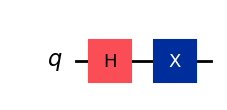

In [8]:
c1=QuantumCircuit(1)
c1.h(0)
c1.x(0)
c1.draw("mpl")
plt.show()

In [9]:
job=bd.run(c1,shot=200)

In [10]:
result = job.result()
counts = result.get_counts()

In [11]:
counts

{np.str_('0'): np.float64(0.5), np.str_('1'): np.float64(0.5)}

In [ ]:
import network
wifi = network.WLAN(network.STA_IF)
wifi.active(True)
print(wifi.scan())